# COMPAS Recidivism Analysis — Python Translation - McHale

This notebook reproduces ProPublica's COMPAS recidivism risk score analysis,
originally written in R, using Python, including analytical steps like data
loading, cleaning, EDA, logistic regression, and running fairness diagnostics.

See `README.md` for setup instructions and a full summary of library differences.

##R used library(dplyr) for data manipulation and library(ggplot2) for visualisation, loaded via the rpy2 bridge (%load_ext rpy2.ipython).

## Python equivalents:
    pandas      → dplyr  (select, filter, mutate, group_by, summarise)
    matplotlib  → ggplot2 + gridExtra  (bar charts, side-by-side layouts)
    statsmodels → base R stats / glm   (logistic regression)
    scipy       → base R stats         (correlation utilities if needed)

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats

In [2]:
# ── Cell 2: Load Data ─────────────────────────────────────────────────────────
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
print(len(raw_data))  # expected: 7214

7214


In [3]:
# ── Cell 3: Preview Raw Data ──────────────────────────────────────────────────
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


# Data Cleaning & Feature Selection
    I applied the same filters as the R script:
    days_b_screening_arrest between -30 and +30: Ensures the COMPAS score was assigned close in time to the actual arrest. Scores generated more than 30 days apart may reflect a different offense entirely.

    is_recid != -1: Removes rows where no matching COMPAS case was found (coded as -1 in the dataset).

    c_charge_degree != 'O': Excludes ordinary traffic offenses, which carry no jail time and are not the target population for recidivism scoring.

    score_text != 'N/A': Removes rows with no COMPAS risk label assigned.

# Feature selection rationale
    The 13 columns retained are the minimal set needed to reproduce the original EDA and model. They cover:

    Demographics: age, age_cat, sex, race

    Criminal history: priors_count, c_charge_degree

    COMPAS output: decile_score, score_text

    Outcome labels: is_recid, two_year_recid

    Temporal: c_jail_in, c_jail_out (for length-of-stay calculation)

    Screening timing: days_b_screening_arrest (used only for filtering)

In [4]:
# ── Cell 5: Filter, Select, and Encode ───────────────────────────────────────
datetime_vars = ["c_jail_in", "c_jail_out"]
numeric_vars  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]

df = (
    raw_data[
        ["age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
         "priors_count", "days_b_screening_arrest", "decile_score",
         "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"]
    ]
    .query("-30 <= days_b_screening_arrest <= 30")  # ±30-day window filter
    .query("is_recid != -1")                         # drop unmatched records
    .query("c_charge_degree != 'O'")                 # drop traffic offenses
    .query("score_text != 'N/A'")                    # drop missing COMPAS labels
    .copy()
)

# Convert jail timestamps to timezone-aware datetimes
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert all remaining non-numeric columns to categorical dtype
cat_cols = [c for c in df.columns if c not in numeric_vars + datetime_vars]
for col in cat_cols:
    df[col] = df[col].astype("category")

# Derived factor columns with explicit reference levels
# crime_factor: no relevel needed; used as a control covariate
df["crime_factor"] = df["c_charge_degree"].astype("category")

# age_factor: ref = "25 - 45" (R: relevel(factor(age_cat), ref="25 - 45"))
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45"] + [c for c in df["age_cat"].cat.categories if c != "25 - 45"],
    ordered=False
)

# race_factor: ref = "Caucasian" (R: relevel(factor(race), ref="Caucasian"))
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].cat.categories if c != "Caucasian"],
    ordered=False
)

# gender_factor: ref = "Male" (R: relevel(factor(sex), ref="Male"))
df["gender_factor"] = pd.Categorical(
    df["sex"].map({"Male": "Male", "Female": "Female"}),
    categories=["Male", "Female"],
    ordered=False
)

# score_factor: binary outcome label — LowScore (0) vs HighScore (1)
# R: factor(score_text != "Low", labels=c("LowScore","HighScore"))
df["score_factor"] = pd.Categorical(
    df["score_text"].apply(lambda x: "HighScore" if x != "Low" else "LowScore"),
    categories=["LowScore", "HighScore"],
    ordered=False
)

print(len(df))  # expected: 6172

6172


In [5]:
# ── Cell 6: Preview Cleaned DataFrame ────────────────────────────────────────
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [11]:
# ── Cell 7: DataFrame Structure ───────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [13]:
# ── Cell 9: Length-of-Stay vs Decile Score Correlation ───────────────────────
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
).dt.days

correlation = df["length_of_stay"].corr(df["decile_score"])
print(f"Pearson r (length_of_stay vs decile_score): {correlation:.4f}")

Pearson r (length_of_stay vs decile_score): 0.2073


After filtering we have the following demographic breakdown:

In [14]:
# ── Cell 11: Age Category Distribution ───────────────────────────────────────
print(df["age_cat"].value_counts())

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [15]:
# ── Cell 12: Race Distribution ────────────────────────────────────────────────
print(df["race"].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [16]:
# ── Cell 13: Race Percentages ─────────────────────────────────────────────────
total = len(df)
vc = df["race"].value_counts()
print("Black defendants: %.2f%%"           % (vc.get("African-American", 0) / total * 100))
print("White defendants: %.2f%%"           % (vc.get("Caucasian",        0) / total * 100))
print("Hispanic defendants: %.2f%%"        % (vc.get("Hispanic",         0) / total * 100))
print("Asian defendants: %.2f%%"           % (vc.get("Asian",            0) / total * 100))
print("Native American defendants: %.2f%%" % (vc.get("Native American",  0) / total * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [17]:
# ── Cell 14: COMPAS Score Category Distribution ───────────────────────────────
print(df["score_text"].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [18]:
# ── Cell 15: Sex x Race Cross-Tabulation ─────────────────────────────────────
print(pd.crosstab(df["sex"], df["race"]))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [19]:
# ── Cell 16: Sex Distribution ─────────────────────────────────────────────────
print(df["sex"].value_counts())

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [20]:
# ── Cell 17: Sex Percentages ──────────────────────────────────────────────────
print("Men: %.2f%%"   % (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [21]:
# ── Cell 18: Two-Year Recidivism Count ────────────────────────────────────────
print(len(df[df["two_year_recid"] == 1]))

2809


In [22]:
# ── Cell 19: Two-Year Recidivism Rate (%) ─────────────────────────────────────
print(len(df[df["two_year_recid"] == 1]) / len(df) * 100)

45.51198963058976


Judges are often presented with two sets of scores from the Compas system. One set classifies people into High, Medium and Low risk, and a second into a corresponding decile score. There is a clear downward trend in decile scores for white defendants.

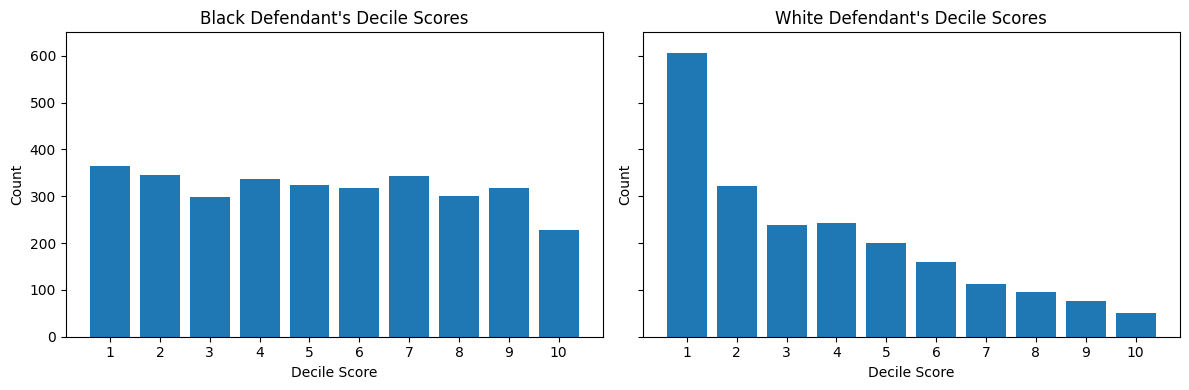

In [24]:
# ── Cell 21: Decile Score Bar Charts by Race ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

for ax, data, title in zip(
    axes,
    [black_df, white_df],
    ["Black Defendant's Decile Scores", "White Defendant's Decile Scores"]
):
    counts = data["decile_score"].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_xlabel("Decile Score")
    ax.set_ylabel("Count")
    ax.set_ylim(0, 650)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [25]:
# ── Cell 22: Decile Score x Race Cross-Tabulation ─────────────────────────────
print(pd.crosstab(df["decile_score"], df["race"]))

race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_score         
1      

# Racial Bias in COMPAS

Next I fit a logistic regression model to test whether race is a significant predictor of receiving a High COMPAS score, after controlling for the other legally relevant factors available in the dataset.

# MODEL CHOICE:
  Binary logistic regression, matching R's glm(..., family = binomial(link = "logit")). This is appropriate because the outcome is binary: High vs Low COMPAS score.

# BUG FIXES:
  Statsmodels requires a numeric 0/1 outcome column: R's glm() accepts a factor response and automatically treats the non-reference level as the positive class (1). statsmodels.formula.api.logit() cannot do this — passing a string/categorical column raises:
    ValueError: endog has evaluated to an array with multiple columns
    Fix: create score_factor_num (0 = LowScore, 1 = HighScore) explicitly before fitting. This is a library implementation difference, not a methodological one — the model is identical.

# PREDICTOR SELECTION (six predictors):
    gender_factor   — controls for sex-based scoring differences
    age_factor      — controls for age group (ref: 25-45, the largest group)
    race_factor     — the key variable of interest; ref: Caucasian
    priors_count    — legally relevant continuous predictor; more priors
                      equals higher predicted risk score
    crime_factor    — controls for offense severity (M=misdemeanor, F=felony)
    two_year_recid  — actual recidivism outcome; included to isolate whether
                      COMPAS scores contain racial bias beyond what is
                      explained by true reoffending behaviour

# LIBRARY DIFFERENCE — model summary format:
    R summary.glm() prints: Estimate | Std. Error | z value | Pr(>|z|) | stars
    statsmodels .summary() prints the same values AND adds: 95% CI columns,
    log-likelihood, AIC, BIC, and a covariance type note (nonrobust). Coefficient values and p-values are numerically equivalent between the two; the extra output from statsmodels is additional diagnostic information, not a discrepancy in the model itself.

In [26]:
# ── Cell 24: Logistic Regression ─────────────────────────────────────────────
# Create numeric 0/1 outcome column required by statsmodels
df["score_factor_num"] = (df["score_factor"] == "HighScore").astype(int)

model_glm = smf.logit(
    "score_factor_num ~ gender_factor + age_factor + race_factor + "
    "priors_count + crime_factor + two_year_recid",
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       score_factor_num   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        15:17:56   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.5255      0.079    -19.430  

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [27]:
# ── Cell 26: Relative Risk — Black vs Caucasian Defendants ───────────────────
control  = math.exp(-1.52554) / (1 + math.exp(-1.52554))
rr_black = math.exp(0.47721)  / (1 - control + (control * math.exp(0.47721)))
print(f"Relative risk (Black vs Caucasian): {rr_black:.4f}")

Relative risk (Black vs Caucasian): 1.4528


Women are 19.4% more likely than men to get a higher score.

In [28]:
# ── Cell 28: Relative Risk — Female vs Male Defendants ───────────────────────
rr_female = math.exp(0.22127) / (1 - control + (control * math.exp(0.22127)))
print(f"Relative risk (Female vs Male): {rr_female:.4f}")

Relative risk (Female vs Male): 1.1948


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [29]:
# ── Cell 30: Relative Risk — Under-25 vs 25-45 Defendants ────────────────────
rr_under25 = math.exp(1.30839) / (1 - control + (control * math.exp(1.30839)))
print(f"Relative risk (Under 25 vs 25-45): {rr_under25:.4f}")

Relative risk (Under 25 vs 25-45): 2.4961


In [31]:
# ── Cell 31: Predicted Probabilities and Classes ──────────────────────────────
df["pred_prob"]  = model_glm.predict(df)
df["pred_class"] = pd.Categorical(
    (df["pred_prob"] >= 0.5).map({True: "Recid", False: "No Recid"}),
    categories=["No Recid", "Recid"]
)

In [32]:
# ── Cell 32: Overall Confusion Matrix and Metrics ─────────────────────────────
print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)
print(overall_cm)

TP = overall_cm.loc["Recid",    1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid",    0]
FN = overall_cm.loc["No Recid", 1]
n  = overall_cm.values.sum()

print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [33]:
# ── Cell 33: Confusion Matrix Metrics by Race ─────────────────────────────────
print("\n── Confusion Matrix by Race ──────────────────────────────────────────")

df["actual"] = df["two_year_recid"].astype(int)
df["pred"]   = (df["pred_class"] == "Recid").astype(int)

def race_metrics_fn(grp):
    TP = ((grp["pred"] == 1) & (grp["actual"] == 1)).sum()
    TN = ((grp["pred"] == 0) & (grp["actual"] == 0)).sum()
    FP = ((grp["pred"] == 1) & (grp["actual"] == 0)).sum()
    FN = ((grp["pred"] == 0) & (grp["actual"] == 1)).sum()
    n  = len(grp)
    return pd.Series({
        "n":         n,
        "TP":        TP,
        "TN":        TN,
        "FP":        FP,
        "FN":        FN,
        "Accuracy":  round((TP + TN) / n, 3),
        "Precision": round(TP / (TP + FP), 3) if (TP + FP) > 0 else float('nan'),
        "Recall":    round(TP / (TP + FN), 3) if (TP + FN) > 0 else float('nan'),
        "FPR":       round(FP / (FP + TN), 3) if (FP + TN) > 0 else float('nan'),
        "FNR":       round(FN / (FN + TP), 3) if (FN + TP) > 0 else float('nan'),
    })

race_metrics_df = (
    df.groupby("race", observed=True)
      .apply(race_metrics_fn)
      .reset_index()
      .sort_values("n", ascending=False)
)
print(race_metrics_df.to_string(index=False))


── Confusion Matrix by Race ──────────────────────────────────────────
            race      n     TP     TN    FP    FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175.0 1373.0  959.0 555.0 288.0     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103.0  381.0 1148.0 133.0 441.0     0.727      0.741   0.464 0.104 0.536
        Hispanic  509.0   81.0  306.0  14.0 108.0     0.760      0.853   0.429 0.044 0.571
           Other  343.0   22.0  216.0   3.0 102.0     0.694      0.880   0.177 0.014 0.823
           Asian   31.0    2.0   22.0   1.0   6.0     0.774      0.667   0.250 0.043 0.750
 Native American   11.0    5.0    2.0   4.0   0.0     0.636      0.556   1.000 0.667 0.000


# Conclusion:
In this final block the code computes the difference in False Positive Rate and False Negative Rate between each racial group and the Caucasian baseline, replicating R's mutate(delta_FPR = FPR - FPR[race=="Caucasian"], ...).

# The interpretation of this can be summarized as:
  positive delta_FPR — that group is falsely flagged as high-risk MORE
                       often than Caucasian defendants (over-prediction)
  positive delta_FNR — that group is falsely cleared MORE often
                       (under-prediction of risk)

These two metrics are the core of the ProPublica bias finding: COMPAS disproportionately over-flags Black defendants (higher FPR) while under-flagging them relative to actual reoffending (lower FNR).

In [34]:
# ── Cell 34: FPR and FNR Disparity by Race ────────────────────────────────────
print("\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

disparity = race_metrics_df[["race", "n", "FPR", "FNR"]].copy()

caucasian_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
caucasian_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

print(disparity.to_string(index=False))


── FPR and FNR Disparity by Race ─────────────────────────────────────
            race      n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175.0 0.367 0.173      0.263     -0.363
       Caucasian 2103.0 0.104 0.536      0.000      0.000
        Hispanic  509.0 0.044 0.571     -0.060      0.035
           Other  343.0 0.014 0.823     -0.090      0.287
           Asian   31.0 0.043 0.750     -0.061      0.214
 Native American   11.0 0.667 0.000      0.563     -0.536
